## 1. Imports and Settings

In [1]:
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

RANDOM_STATE = 42
BW_HATCHES = ["///", "\\\\\\", "xx", "..", "++", "oo"]
BW_COLORS = ["white", "#E6E6E6", "#BFBFBF", "#8C8C8C", "#666666", "#D9D9D9"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

## 1.1 Helper Functions

In [2]:
def add_bar_labels(ax, fmt="{:,.0f}"):
    for patch in ax.patches:
        width = patch.get_width()
        height = patch.get_height()
        if np.isnan(width) or np.isnan(height):
            continue
        if width >= height:
            ax.annotate(
                fmt.format(width),
                (width, patch.get_y() + height / 2),
                ha="left",
                va="center",
                fontsize=9,
                xytext=(4, 0),
                textcoords="offset points",
            )
        else:
            ax.annotate(
                fmt.format(height),
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )


def plot_count_bar(counts, title, xlabel="", ylabel="", horizontal=False, top_n=None):
    plot_counts = counts.copy()
    if top_n is not None:
        plot_counts = plot_counts.head(top_n)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(plot_counts))) if horizontal else (8, 4.5))
    colors = [BW_COLORS[i % len(BW_COLORS)] for i in range(len(plot_counts))]

    if horizontal:
        bars = ax.barh(
            plot_counts.index.astype(str),
            plot_counts.values,
            color=colors,
            edgecolor="black",
            linewidth=1.0,
        )
        ax.invert_yaxis()
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.margins(x=0.15)
    else:
        bars = ax.bar(
            plot_counts.index.astype(str),
            plot_counts.values,
            color=colors,
            edgecolor="black",
            linewidth=1.0,
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
        ax.margins(y=0.15)

    for idx, bar in enumerate(bars):
        bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])

    ax.set_title(title)
    add_bar_labels(ax)
    plt.tight_layout()
    plt.show()


def derive_malware_type(category_value):
    category_value = str(category_value)
    if category_value == "Benign":
        return "Benign"
    return category_value.split("-", 1)[0]


def read_csv_preview(path, sep=","):
    path = Path(path)
    try:
        preview = pd.read_csv(path, sep=sep, nrows=5)
        rows = sum(1 for _ in path.open("rb")) - 1
        return {
            "dataset": str(path),
            "rows": rows,
            "columns": preview.shape[1],
            "sample_columns": ", ".join(map(str, preview.columns[:6])),
        }
    except Exception as exc:
        return {
            "dataset": str(path),
            "rows": np.nan,
            "columns": np.nan,
            "sample_columns": f"Could not read: {exc}",
        }


def clean_numeric_features(data, target_col):
    feature_df = data.drop(columns=[target_col, "Category", "Class"], errors="ignore").copy()
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
    feature_df = feature_df.apply(pd.to_numeric, errors="coerce")
    feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
    feature_df = feature_df.fillna(0)
    return feature_df


def evaluate_random_forest(model, X_test, y_test, label_encoder):
    y_pred = model.predict(X_test)
    labels = np.arange(len(label_encoder.classes_))
    class_names = label_encoder.classes_

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    metrics = pd.DataFrame(
        [{
            "accuracy": accuracy_score(y_test, y_pred),
            "weighted_precision": precision,
            "weighted_recall": recall,
            "weighted_f1": f1,
            "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }]
    )
    display(metrics.round(4))

    print("Classification Report")
    report = classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report).T.round(4))

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Greys", values_format="d", xticks_rotation=30, colorbar=False)
    plt.title("Random Forest Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return y_pred, metrics


def plot_estimator_error_curve(X_train, X_test, y_train, y_test, n_values):
    rows = []
    for n_estimators in n_values:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            criterion="gini",
            max_features="sqrt",
            min_samples_leaf=2,
            class_weight="balanced",
            bootstrap=True,
            oob_score=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rows.append(
            {
                "n_estimators": n_estimators,
                "test_error": 1 - accuracy_score(y_test, preds),
                "misclassifications": int((preds != y_test).sum()),
                "weighted_f1": f1_score(y_test, preds, average="weighted", zero_division=0),
                "oob_score": model.oob_score_,
            }
        )

    curve_df = pd.DataFrame(rows)
    display(curve_df.round(4))

    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    ax1.plot(
        curve_df["n_estimators"],
        curve_df["test_error"],
        color="black",
        marker="o",
        linestyle="-",
        linewidth=1.8,
        label="Test error",
    )
    ax1.plot(
        curve_df["n_estimators"],
        1 - curve_df["oob_score"],
        color="#666666",
        marker="s",
        linestyle="--",
        linewidth=1.8,
        label="OOB error",
    )
    ax1.set_title("Choosing Number of Trees")
    ax1.set_xlabel("Number of trees")
    ax1.set_ylabel("Error")
    ax1.legend()
    plt.tight_layout()
    plt.show()

    return curve_df


def plot_feature_importance(model, feature_names, top_n=20):
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importances.head(top_n).rename("importance").reset_index().rename(columns={"index": "feature"}))
    plot_count_bar(
        importances.head(top_n).iloc[::-1],
        title=f"Top {top_n} Random Forest Feature Importances",
        xlabel="Importance",
        horizontal=True,
    )
    return importances


def plot_random_forest_tree(model, feature_names, class_names, tree_index=0, max_depth=3):
    estimator = model.estimators_[tree_index]
    plt.figure(figsize=(22, 10))
    plot_tree(
        estimator,
        feature_names=feature_names,
        class_names=[str(name) for name in class_names],
        max_depth=max_depth,
        filled=False,
        rounded=False,
        fontsize=8,
        impurity=True,
        proportion=False,
    )
    plt.title(f"Random Forest Tree Visualization: Tree {tree_index} First {max_depth} Levels")
    plt.tight_layout()
    plt.show()


def plot_feature_boxplots(data, feature_cols, target_col):
    top_features = feature_cols[:4]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.ravel()
    for idx, feature in enumerate(top_features):
        labels = sorted(data[target_col].unique())
        box_data = [data.loc[data[target_col] == label, feature] for label in labels]
        box = axes[idx].boxplot(
            box_data,
            tick_labels=labels,
            patch_artist=True,
            medianprops={"color": "black", "linewidth": 1.4},
            boxprops={"edgecolor": "black", "linewidth": 1.0},
            whiskerprops={"color": "black"},
            capprops={"color": "black"},
            flierprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 2,
            },
        )
        for patch_idx, patch in enumerate(box["boxes"]):
            patch.set_facecolor(BW_COLORS[patch_idx % len(BW_COLORS)])
            patch.set_hatch(BW_HATCHES[patch_idx % len(BW_HATCHES)])
        axes[idx].set_title(feature)
        axes[idx].tick_params(axis="x", rotation=25)
        axes[idx].set_ylabel("Value")
    plt.tight_layout()
    plt.show()

## 2. Dataset Inventory

In [3]:
data_root_candidates = [
    Path("MalwareAnalysis/data"),
    Path("../data"),
    Path.cwd() / "MalwareAnalysis" / "data",
]
DATA_ROOT = next(path for path in data_root_candidates if path.exists())
print("Using data folder:", DATA_ROOT.resolve())

dataset_specs = [
    ("Comprehensive malware datasets", DATA_ROOT / "Comprehensive_malware_datasets" / "malware analysis.csv", ","),
    ("Cyber incidents", DATA_ROOT / "Cyber_incidents_2005_to_2020" / "cyber-operations-incidents.csv", ","),
    ("Android permissions", DATA_ROOT / "Dataset_malware_beningn_permissions_Android" / "train.csv", ";"),
    ("Malicious server hack train", DATA_ROOT / "Malicious_Server_Hack" / "Train.csv", ","),
    ("Malicious URLs", DATA_ROOT / "Malicious_URLs_dataset" / "malicious_phish.csv", ","),
    ("API call sequences", DATA_ROOT / "Malware_Analysis_Datasets_API_Call_Sequences" / "dynamic_api_call_sequence_per_malware_100_0_306.csv", ","),
    ("Malware detection", DATA_ROOT / "Malware_Detection" / "Malware dataset.csv", ","),
    ("Executable detection", DATA_ROOT / "Malware_Executable_Detection" / "uci_malware_detection.csv", ","),
    ("Memory analysis", DATA_ROOT / "Malware_Memory_Analysis _CIC-MalMem-2022" / "Obfuscated-MalMem2022.csv", ","),
    ("Opcode families", DATA_ROOT / "Malware_Opcodes" / "all_data.csv", ","),
    ("Android network traffic", DATA_ROOT / "Network_Traffic_Android_Malware" / "android_traffic.csv", ";"),
]

inventory = []
for name, path, sep in dataset_specs:
    row = read_csv_preview(path, sep=sep)
    row["name"] = name
    inventory.append(row)

inventory_df = pd.DataFrame(inventory)[["name", "dataset", "rows", "columns", "sample_columns"]]
display(inventory_df)

Using data folder: /home/durgaumadev/security-for-data-science-lab/MalwareAnalysis/data


,name,dataset,rows,columns,sample_columns
0,Comprehensive malware datasets,../data/Comprehensive_malware_datasets/malware analysis.csv,60937,19,"0, udp, private, SF, 105, 146"
1,Cyber incidents,../data/Cyber_incidents_2005_to_2020/cyber-operations-incidents.csv,547,12,"Title, Date, Affiliations, Description, Response, Victims"
2,Android permissions,../data/Dataset_malware_beningn_permissions_Android/train.csv,398,331,"android, android.app.cts.permission.TEST_GRANTED, android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE, andro..."
3,Malicious server hack train,../data/Malicious_Server_Hack/Train.csv,23856,18,"INCIDENT_ID, DATE, X_1, X_2, X_3, X_4"
4,Malicious URLs,../data/Malicious_URLs_dataset/malicious_phish.csv,651198,2,"url, type"
5,API call sequences,../data/Malware_Analysis_Datasets_API_Call_Sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv,43876,102,"hash, t_0, t_1, t_2, t_3, t_4"
6,Malware detection,../data/Malware_Detection/Malware dataset.csv,100000,35,"hash, millisecond, classification, state, usage_counter, prio"
7,Executable detection,../data/Malware_Executable_Detection/uci_malware_detection.csv,373,532,"Label, F_1, F_2, F_3, F_4, F_5"
8,Memory analysis,../data/Malware_Memory_Analysis _CIC-MalMem-2022/Obfuscated-MalMem2022.csv,58596,57,"Category, pslist.nproc, pslist.nppid, pslist.avg_threads, pslist.nprocs64bit, pslist.avg_handlers"
9,Opcode families,../data/Malware_Opcodes/all_data.csv,9725,1034,"File Name, Family, Total Opcodes, mov, push, call"


## 3. Malware Types Found in the Data Folder

High-level malware types in CIC-MalMem memory dataset


,malware_type,count
0,Benign,29298
1,Spyware,10020
2,Ransomware,9791
3,Trojan,9487


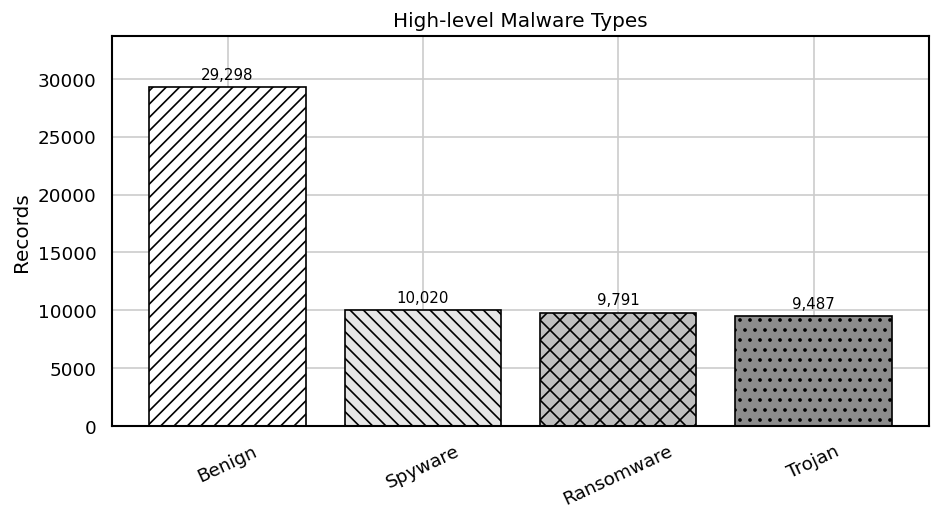

Malware families in opcode dataset


,family,count
0,ALLAPLE_A,986
1,VBINJECT,937
2,VOBFUS,929
3,CEEINJECT,873
4,WINWEBSEC,837
5,VUNDO,762
6,CYCBOT_G,597
7,FAKEREAN,553
8,RENOS,532
9,TOGA_RFN,406


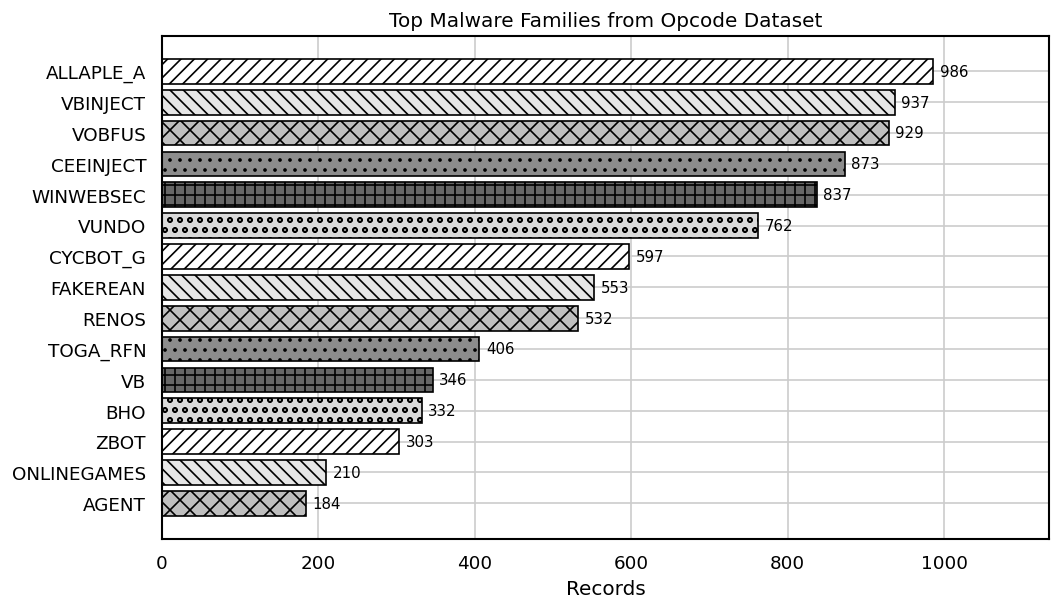

URL security classes in malicious URL dataset


,url_type,count
0,benign,428103
1,defacement,96457
2,phishing,94111
3,malware,32520


Android network traffic classes


,traffic_type,count
0,benign,4704
1,malicious,3141


In [4]:
memory_path = DATA_ROOT / "Malware_Memory_Analysis _CIC-MalMem-2022" / "Obfuscated-MalMem2022.csv"
opcodes_path = DATA_ROOT / "Malware_Opcodes" / "all_data.csv"
url_path = DATA_ROOT / "Malicious_URLs_dataset" / "malicious_phish.csv"
traffic_path = DATA_ROOT / "Network_Traffic_Android_Malware" / "android_traffic.csv"

memory_labels = pd.read_csv(memory_path, usecols=["Category", "Class"])
memory_labels["malware_type"] = memory_labels["Category"].map(derive_malware_type)
print("High-level malware types in CIC-MalMem memory dataset")
display(memory_labels["malware_type"].value_counts().rename_axis("malware_type").reset_index(name="count"))
plot_count_bar(memory_labels["malware_type"].value_counts(), "High-level Malware Types", ylabel="Records")

opcode_families = pd.read_csv(opcodes_path, usecols=["Family"])
print("Malware families in opcode dataset")
display(opcode_families["Family"].value_counts().rename_axis("family").reset_index(name="count"))
plot_count_bar(opcode_families["Family"].value_counts(), "Top Malware Families from Opcode Dataset", xlabel="Records", horizontal=True, top_n=15)

url_types = pd.read_csv(url_path, usecols=["type"])
print("URL security classes in malicious URL dataset")
display(url_types["type"].value_counts().rename_axis("url_type").reset_index(name="count"))

traffic_types = pd.read_csv(traffic_path, sep=";", usecols=["type"])
print("Android network traffic classes")
display(traffic_types["type"].value_counts().rename_axis("traffic_type").reset_index(name="count"))

## 4. Load Main Malware-Type Dataset

In [5]:
df = pd.read_csv(memory_path)
df["malware_type"] = df["Category"].map(derive_malware_type)

print("Dataset shape:", df.shape)
print("Target classes:", sorted(df["malware_type"].unique()))
display(df.head())

Dataset shape: (58596, 58)
Target classes: ['Benign', 'Ransomware', 'Spyware', 'Trojan']


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,handles.nfile,handles.nevent,handles.ndesktop,handles.nkey,handles.nthread,handles.ndirectory,handles.nsemaphore,handles.ntimer,handles.nsection,handles.nmutant,ldrmodules.not_in_load,ldrmodules.not_in_init,ldrmodules.not_in_mem,ldrmodules.not_in_load_avg,ldrmodules.not_in_init_avg,ldrmodules.not_in_mem_avg,malfind.ninjections,malfind.commitCharge,malfind.protection,malfind.uniqueInjections,psxview.not_in_pslist,psxview.not_in_eprocess_pool,psxview.not_in_ethread_pool,psxview.not_in_pspcid_list,psxview.not_in_csrss_handles,psxview.not_in_session,psxview.not_in_deskthrd,psxview.not_in_pslist_false_avg,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_ethread_pool_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_csrss_handles_false_avg,psxview.not_in_session_false_avg,psxview.not_in_deskthrd_false_avg,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,malware_type
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,670,3161,46,716,887,104,671,125,184,257,53,95,53,0.030372,0.054441,0.030372,5,21,30,1.250000,2,0,3,2,7,4,9,0.042553,0.0,0.063830,0.042553,0.148936,0.085106,0.191489,138,389,221,26,24,116,0,121,87,0,8,Benign,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,840,3761,51,1011,1030,117,766,148,337,394,77,123,77,0.036167,0.057774,0.036167,12,77,72,1.714286,0,0,0,0,4,2,6,0.000000,0.0,0.000000,0.000000,0.085106,0.042553,0.127660,138,392,222,26,24,118,0,122,87,0,8,Benign,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,1050,3996,45,784,1241,100,645,138,369,338,51,89,51,0.026114,0.045571,0.026114,5,6,30,1.250000,0,0,0,0,4,2,5,0.000000,0.0,0.000000,0.000000,0.100000,0.050000,0.125000,137,395,222,26,27,118,0,120,88,0,8,Benign,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,630,2961,36,654,792,83,567,127,186,242,31,62,31,0.021483,0.042966,0.021483,2,2,12,1.000000,0,0,0,0,4,2,6,0.000000,0.0,0.000000,0.000000,0.125000,0.062500,0.187500,138,395,222,26,27,118,0,120,88,0,8,Benign,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,908,3834,45,1252,942,103,825,135,375,429,102,143,102,0.047820,0.067042,0.047820,12,77,72,2.000000,4,0,4,4,8,6,10,0.086957,0.0,0.086957,0.086957,0.173913,0.130435,0.217391,138,392,222,26,24,118,0,124,87,0,8,Benign,Benign


## 5. Basic EDA

Columns: ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_f

,missing,missing_pct
Category,0,0.0
pslist.nproc,0,0.0
pslist.nppid,0,0.0
pslist.avg_threads,0,0.0
pslist.nprocs64bit,0,0.0
pslist.avg_handlers,0,0.0
dlllist.ndlls,0,0.0
dlllist.avg_dlls_per_proc,0,0.0
handles.nhandles,0,0.0
handles.avg_handles_per_proc,0,0.0



Class distribution


,malware_type,count
0,Benign,29298
1,Spyware,10020
2,Ransomware,9791
3,Trojan,9487


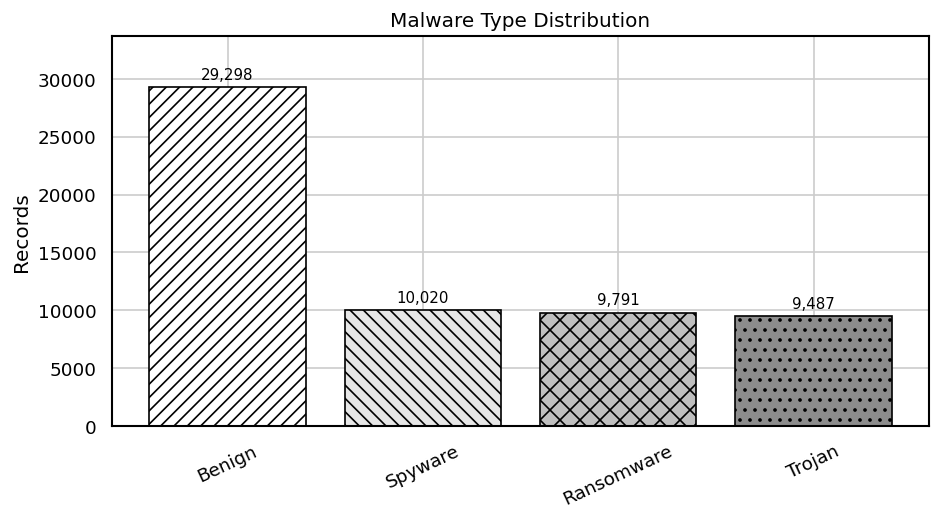


Benign vs malware distribution


,class,count
0,Benign,29298
1,Malware,29298


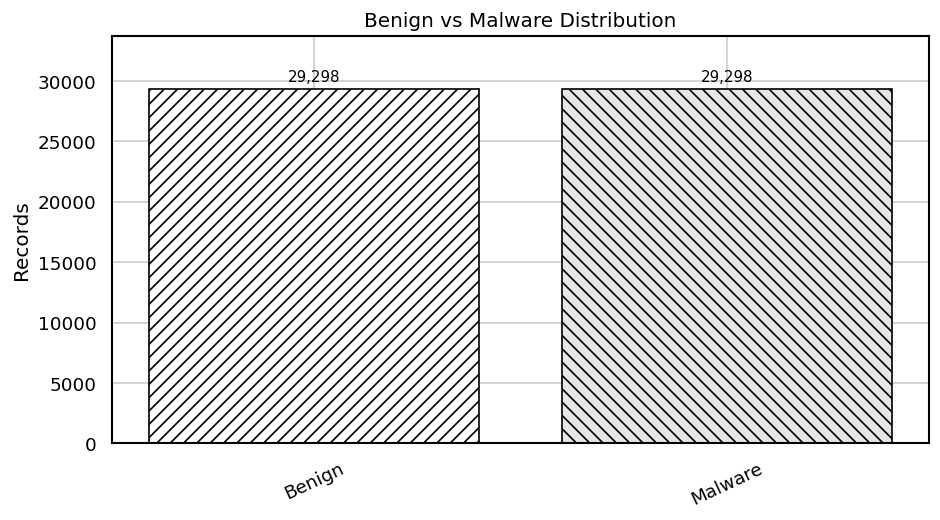

In [6]:
print("Columns:", df.columns.tolist())
print("\nMissing values")
missing_summary = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("missing", ascending=False)
display(missing_summary.head(15))

print("\nClass distribution")
type_counts = df["malware_type"].value_counts()
display(type_counts.rename_axis("malware_type").reset_index(name="count"))
plot_count_bar(type_counts, "Malware Type Distribution", ylabel="Records")

print("\nBenign vs malware distribution")
class_counts = df["Class"].value_counts()
display(class_counts.rename_axis("class").reset_index(name="count"))
plot_count_bar(class_counts, "Benign vs Malware Distribution", ylabel="Records")

## 6. Feature Analysis

Number of numeric features: 55


,mean,std,min,max
pslist.nproc,41.395,5.777,21.000,240.000
pslist.nppid,14.714,2.657,8.000,72.000
pslist.avg_threads,11.342,1.588,1.650,16.818
pslist.nprocs64bit,0.000,0.000,0.000,0.000
pslist.avg_handlers,247.510,111.858,34.962,24845.951
dlllist.ndlls,1810.805,329.783,670.000,3443.000
dlllist.avg_dlls_per_proc,43.708,5.742,7.333,53.171
handles.nhandles,10258.584,4866.864,3514.000,1047310.000
handles.avg_handles_per_proc,249.561,146.000,71.139,33784.194
handles.nport,0.000,0.000,0.000,0.000


Highest-variance features


,feature,variance
0,malfind.commitCharge,3.650118e+07
1,handles.nhandles,2.368637e+07
2,handles.nfile,1.178103e+07
3,handles.nevent,6.487667e+05
4,dlllist.ndlls,1.087566e+05
5,handles.nthread,5.655719e+04
6,handles.nkey,2.262229e+04
7,handles.avg_handles_per_proc,2.131596e+04
8,handles.nsection,2.081638e+04
9,pslist.avg_handlers,1.251217e+04


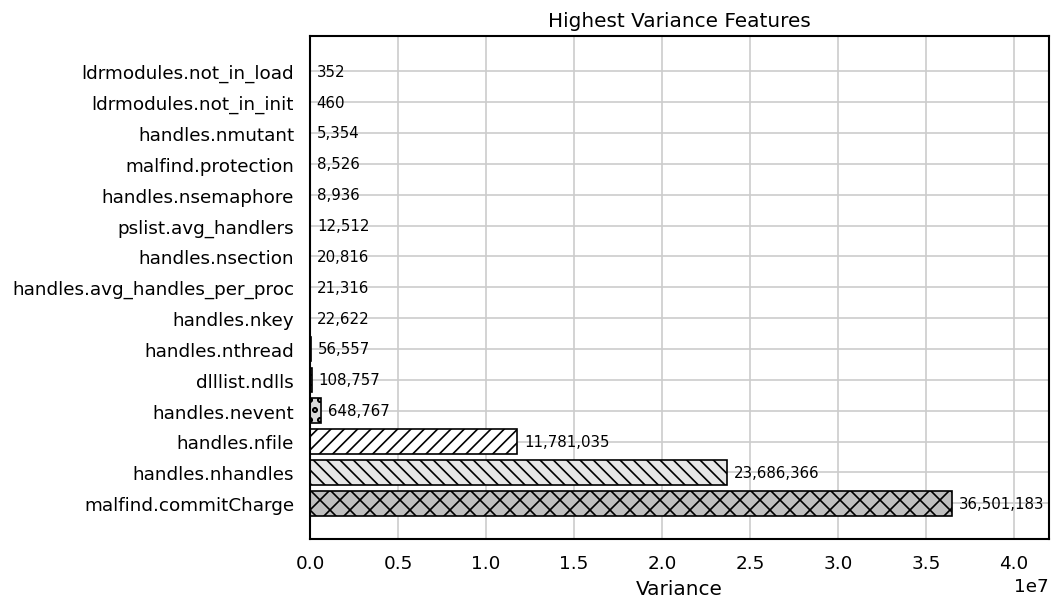

In [7]:
feature_df = clean_numeric_features(df, target_col="malware_type")
feature_cols = feature_df.columns.tolist()

print("Number of numeric features:", len(feature_cols))
display(feature_df.describe().T[["mean", "std", "min", "max"]].round(3).head(20))

variance_rank = feature_df.var().sort_values(ascending=False)
print("Highest-variance features")
display(variance_rank.head(15).rename("variance").reset_index().rename(columns={"index": "feature"}))
plot_count_bar(variance_rank.head(15).iloc[::-1], "Highest Variance Features", xlabel="Variance", horizontal=True)

## 7. Train-Test Split

In [8]:
X = feature_df
y_text = df["malware_type"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Encoded labels:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Train size: (46876, 55)
Test size: (11720, 55)
Encoded labels: {'Benign': np.int64(0), 'Ransomware': np.int64(1), 'Spyware': np.int64(2), 'Trojan': np.int64(3)}


## 8. Random Forest Model

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Random Forest training completed")
print("Out-of-bag score:", round(rf_model.oob_score_, 4))

print("Main Random Forest parameters")
display(pd.Series(rf_model.get_params()).to_frame("value").loc[
    ["n_estimators", "criterion", "max_features", "max_depth", "min_samples_leaf", "class_weight", "bootstrap", "oob_score"]
])

Random Forest training completed
Out-of-bag score: 0.8773
Main Random Forest parameters


,value
n_estimators,200
criterion,gini
max_features,sqrt
max_depth,None
min_samples_leaf,2
class_weight,balanced
bootstrap,True
oob_score,True


## 9. Model Evaluation

,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_f1
0,0.8705,0.8703,0.8705,0.8703,0.8051


Classification Report


,precision,recall,f1-score,support
Benign,1.0000,0.9998,0.9999,5860.0000
Ransomware,0.7221,0.7232,0.7226,1958.0000
Spyware,0.7736,0.7944,0.7839,2004.0000
Trojan,0.7248,0.7034,0.7139,1898.0000
accuracy,0.8705,0.8705,0.8705,0.8705
macro avg,0.8051,0.8052,0.8051,11720.0000
weighted avg,0.8703,0.8705,0.8703,11720.0000


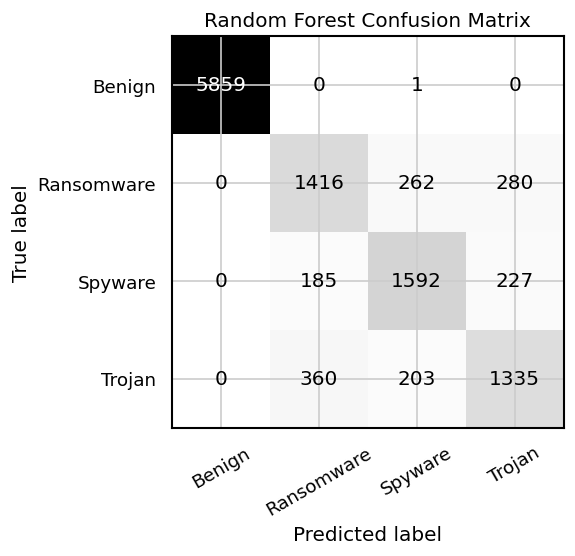

In [10]:
y_pred, metrics_df = evaluate_random_forest(rf_model, X_test, y_test, label_encoder)

## 10. Choosing the Correct Number of Trees

/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,test_error,misclassifications,weighted_f1,oob_score
0,25,0.1343,1574,0.8656,0.8652
1,50,0.1329,1558,0.8669,0.8703
2,75,0.1307,1532,0.8691,0.8745
3,100,0.1297,1520,0.8702,0.8755
4,150,0.1299,1522,0.8700,0.8769
5,200,0.1295,1518,0.8703,0.8773


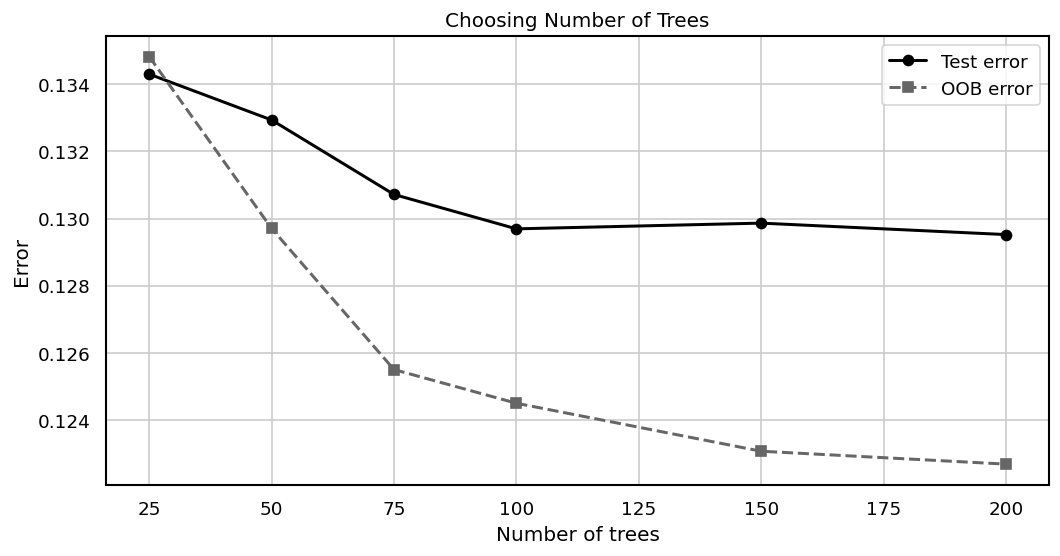

In [11]:
n_values = [25, 50, 75, 100, 150, 200]
tree_count_results = plot_estimator_error_curve(X_train, X_test, y_train, y_test, n_values)

## 11. Hyperparameter Tuning with GridSearchCV

Best GridSearchCV parameters


{'bootstrap': True,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'n_estimators': 200,
 'oob_score': True}

Best cross-validation weighted F1: 0.8387


Tuned model out-of-bag score: 0.8828


,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_f1
0,0.8794,0.8792,0.8794,0.8792,0.8185


Classification Report


,precision,recall,f1-score,support
Benign,1.0000,0.9998,0.9999,5860.0000
Ransomware,0.7427,0.7431,0.7429,1958.0000
Spyware,0.7805,0.8054,0.7927,2004.0000
Trojan,0.7514,0.7260,0.7385,1898.0000
accuracy,0.8794,0.8794,0.8794,0.8794
macro avg,0.8186,0.8186,0.8185,11720.0000
weighted avg,0.8792,0.8794,0.8792,11720.0000


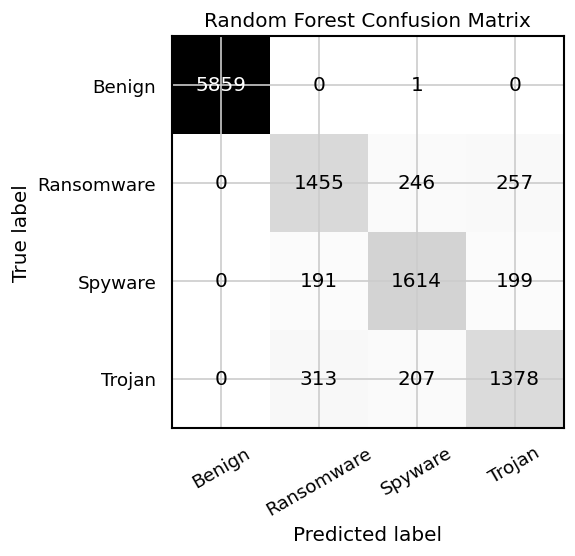

,Model,Accuracy,Weighted F1,Macro F1
0,Baseline Random Forest,0.8705,0.8703,0.8051
1,Tuned Random Forest,0.8794,0.8792,0.8185


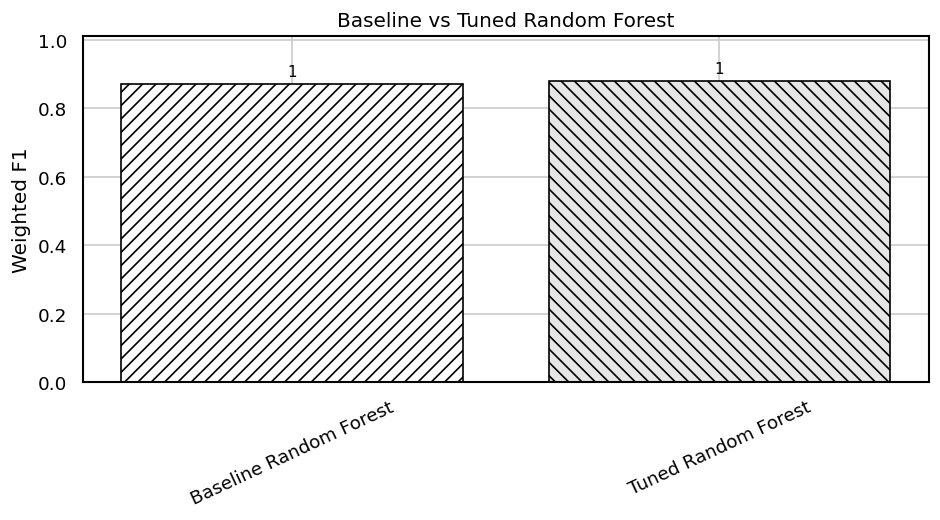

In [12]:
tuning_size = min(12000, X_train.shape[0])
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=tuning_size,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True],
    "oob_score": [True],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
)

grid_rf.fit(X_tune, y_tune)
print("Best GridSearchCV parameters")
display(grid_rf.best_params_)
print("Best cross-validation weighted F1:", round(grid_rf.best_score_, 4))

tuned_model = grid_rf.best_estimator_
tuned_model.fit(X_train, y_train)
print("Tuned model out-of-bag score:", round(tuned_model.oob_score_, 4))

tuned_pred, tuned_metrics_df = evaluate_random_forest(tuned_model, X_test, y_test, label_encoder)

comparison_df = pd.concat(
    [
        metrics_df.assign(model="Baseline Random Forest"),
        tuned_metrics_df.assign(model="Tuned Random Forest"),
    ],
    ignore_index=True,
)

model_comparison = (
    comparison_df[["model", "accuracy", "weighted_f1", "macro_f1"]]
    .rename(
        columns={
            "model": "Model",
            "accuracy": "Accuracy",
            "weighted_f1": "Weighted F1",
            "macro_f1": "Macro F1",
        }
    )
    .round(4)
)

display(model_comparison)

plot_count_bar(
    model_comparison.set_index("Model")["Weighted F1"],
    title="Baseline vs Tuned Random Forest",
    ylabel="Weighted F1",
)

## 12. Important Features

Feature importance shown for: Tuned Random Forest


,feature,importance
0,svcscan.nservices,0.140487
1,svcscan.shared_process_services,0.112008
2,handles.nfile,0.043391
3,handles.nevent,0.040865
4,handles.nmutant,0.040063
5,handles.nkey,0.039716
6,svcscan.kernel_drivers,0.039465
7,ldrmodules.not_in_mem_avg,0.036907
8,handles.nsemaphore,0.035458
9,ldrmodules.not_in_load_avg,0.035393


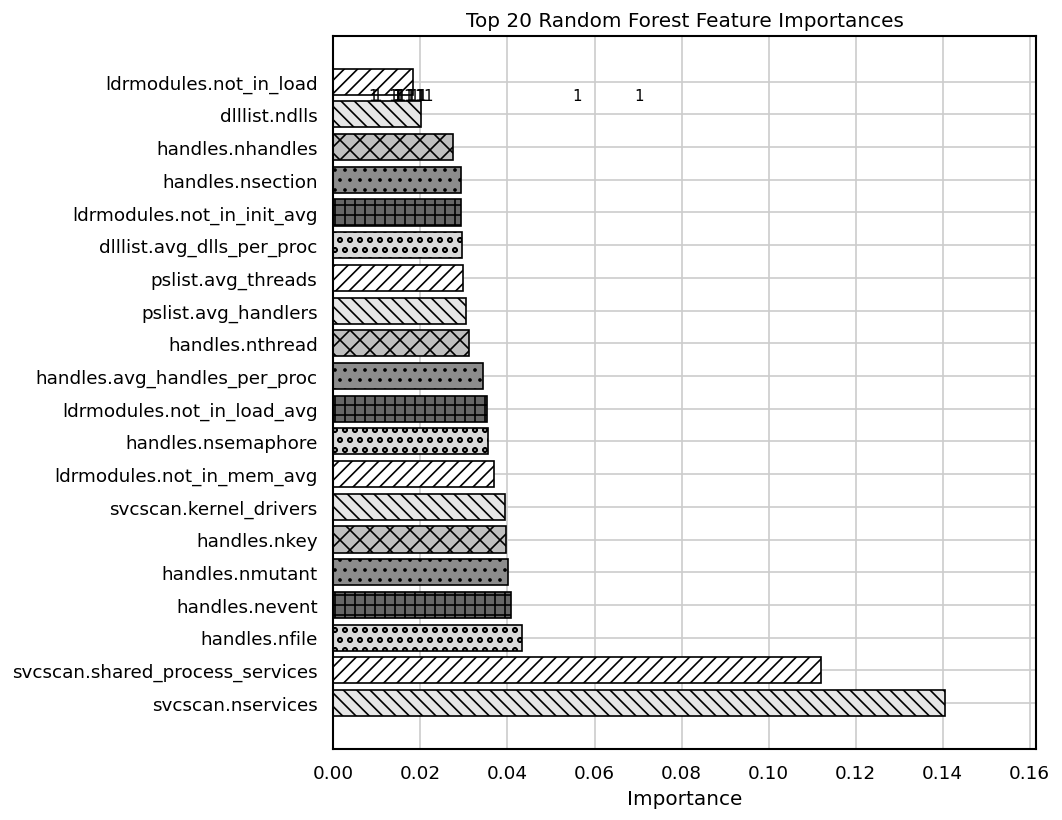

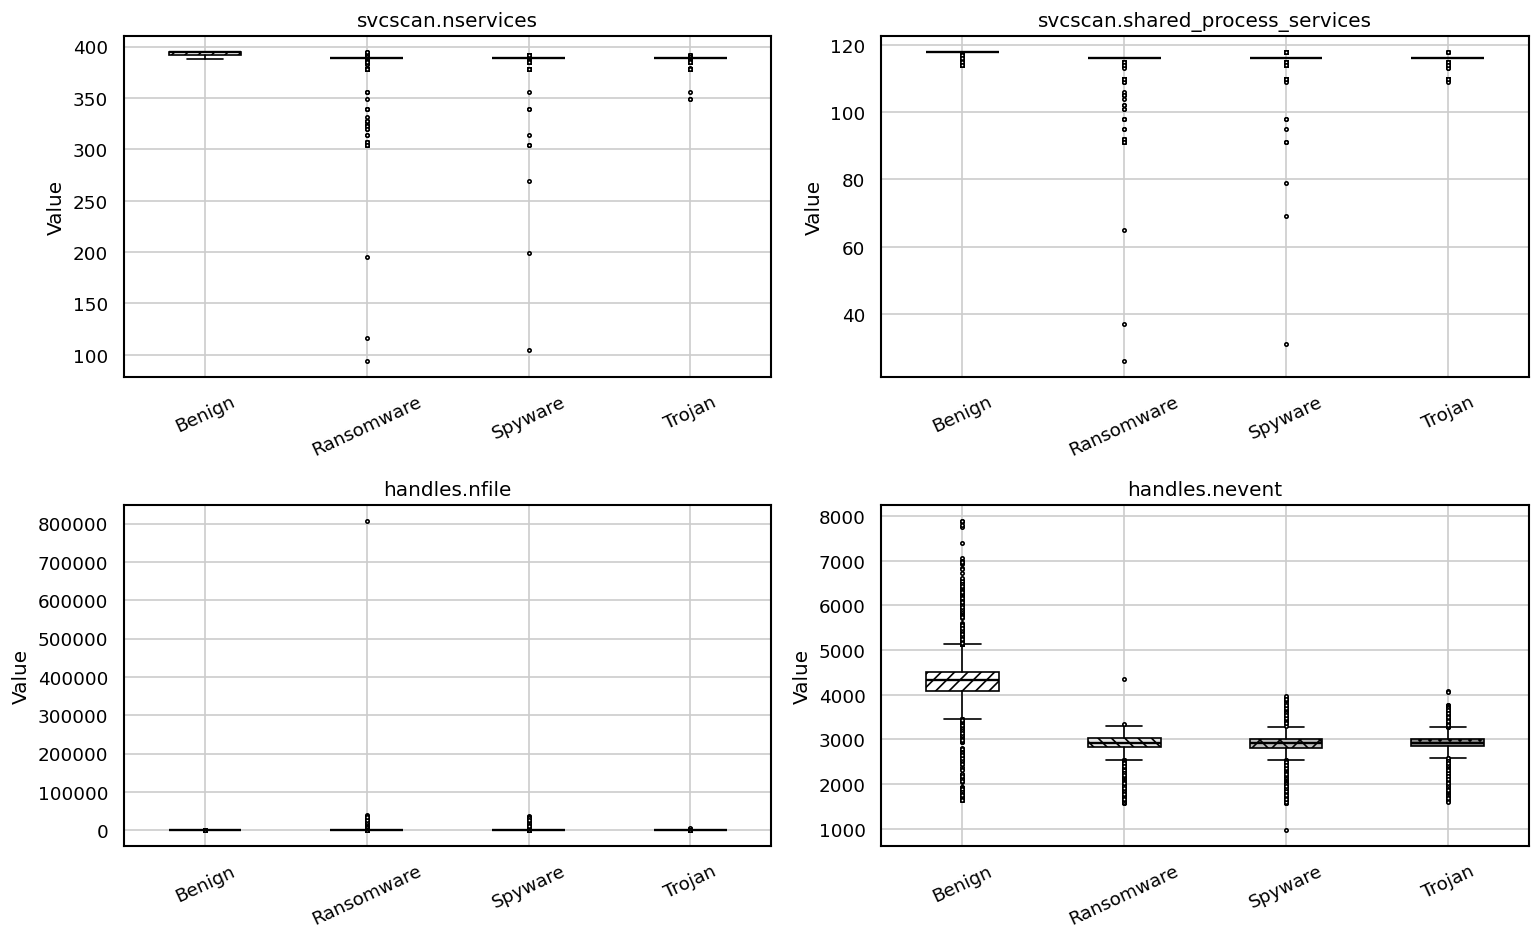

In [13]:
best_rf_model = tuned_model if tuned_metrics_df.loc[0, "weighted_f1"] >= metrics_df.loc[0, "weighted_f1"] else rf_model
best_rf_name = "Tuned Random Forest" if best_rf_model is tuned_model else "Baseline Random Forest"
print("Feature importance shown for:", best_rf_name)

feature_importances = plot_feature_importance(best_rf_model, feature_cols, top_n=20)
important_features = feature_importances.head(4).index.tolist()

analysis_df = df[["malware_type"] + important_features].copy()
plot_feature_boxplots(analysis_df, important_features, "malware_type")

## 13. Random Forest Tree Visualization

Showing one representative tree from: Tuned Random Forest
Note: Random Forest contains many trees, so this graph shows only one tree from the forest.


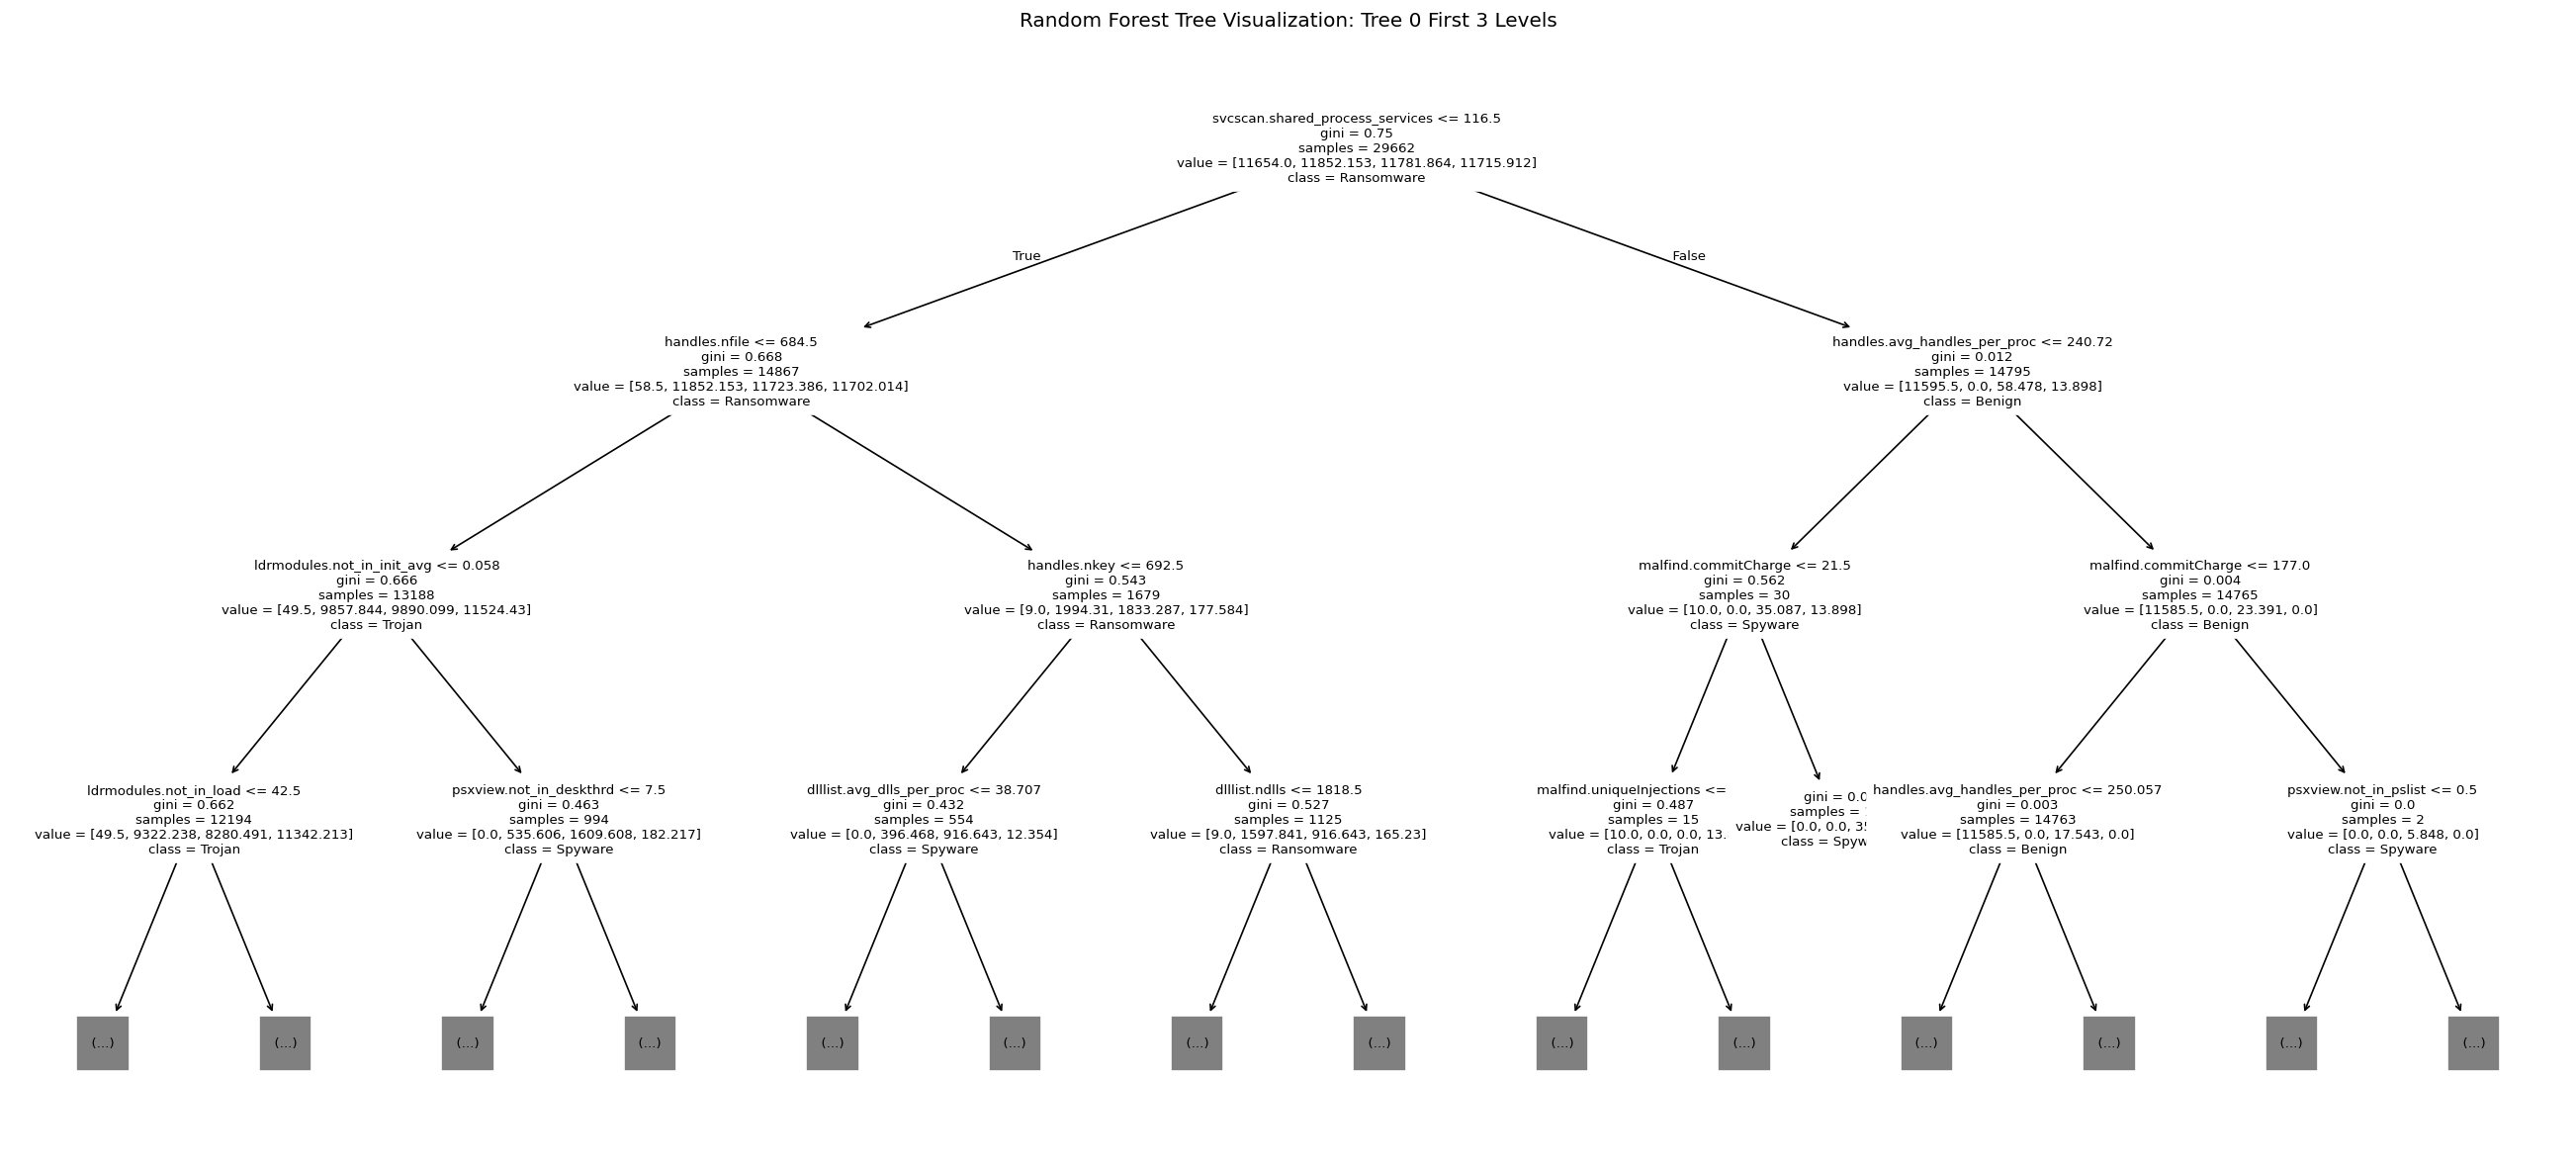

In [14]:
print(f"Showing one representative tree from: {best_rf_name}")
print("Note: Random Forest contains many trees, so this graph shows only one tree from the forest.")
plot_random_forest_tree(
    best_rf_model,
    feature_names=feature_cols,
    class_names=label_encoder.classes_,
    tree_index=0,
    max_depth=3,
)

## 14. Prediction Examples

In [15]:
examples = X_test.head(10).copy()
example_predictions = pd.DataFrame({
    "actual_type": label_encoder.inverse_transform(y_test[:10]),
    "predicted_type": label_encoder.inverse_transform(best_rf_model.predict(examples)),
})
display(example_predictions)

error_df = pd.DataFrame({
    "actual_type": label_encoder.inverse_transform(y_test),
    "predicted_type": label_encoder.inverse_transform(best_rf_model.predict(X_test)),
})
error_df = error_df[error_df["actual_type"] != error_df["predicted_type"]]
print("Misclassified samples:", len(error_df))
display(error_df.head(15))

,actual_type,predicted_type
0,Benign,Benign
1,Benign,Benign
2,Benign,Benign
3,Spyware,Spyware
4,Benign,Benign
5,Spyware,Ransomware
6,Benign,Benign
7,Benign,Benign
8,Ransomware,Ransomware
9,Trojan,Ransomware


Misclassified samples: 1414


,actual_type,predicted_type
5,Spyware,Ransomware
9,Trojan,Ransomware
14,Spyware,Trojan
27,Trojan,Spyware
29,Trojan,Ransomware
30,Spyware,Trojan
38,Spyware,Trojan
50,Spyware,Trojan
63,Trojan,Spyware
68,Spyware,Ransomware
